In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/ML/Dummy data set/Per_Trail_EEG-3.xlsx")

In [ ]:
# ASD/TD to 1/0 for ML
df['Label_Class'] = df['DataSet'].apply(
    lambda x: 1 if pd.notna(x) and 'ASD' in x else (0 if pd.notna(x) and 'TD' in x else None)
)

# Create Subject_ID column from DataSet
extracted_id = df['DataSet'].str.extract(r'([A-Za-z]+)(\d+)')
df['Subject_ID'] = extracted_id[0] + extracted_id[1].fillna('')


# Select features
features = [
    'AF7_Alpha', 'AF7_Beta', 'AF7_Theta',
    'AF8_Alpha', 'AF8_Beta', 'AF8_Theta',
    'Theta/Alpha_AF7', 'Alpha/Beta_AF7',
    'Theta/Alpha_AF8', 'Alpha/Beta_AF8'
]

X = df[features]
y = df['Label_Class']
groups = df['Subject_ID']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


#  Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 🔍 GridSearchCV to tune SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

param_grid_svm = {
    'svm__C': [0.01, 0.1, 1, 10, 100, 1000],
    'svm__gamma': [0.0001, 0.001, 0.01, 0.1, 1, 'scale', 'auto'],
    'svm__kernel': ['linear', 'rbf'], # Removed 'poly' kernel
    'svm__class_weight': [None, 'balanced']
}


svm = SVC(probability=True, random_state=42, class_weight='balanced')

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm)
])

grid = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("✅ Best Hyperparameters:", grid.best_params_)
print("🏆 Best Cross-Validated Accuracy: {:.2f}".format(grid.best_score_))

best_svm_model = grid.best_estimator_

✅ Best Hyperparameters: {'svm__C': 1, 'svm__class_weight': None, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
🏆 Best Cross-Validated Accuracy: 0.87


✅ Best K = 3 with accuracy = 0.83


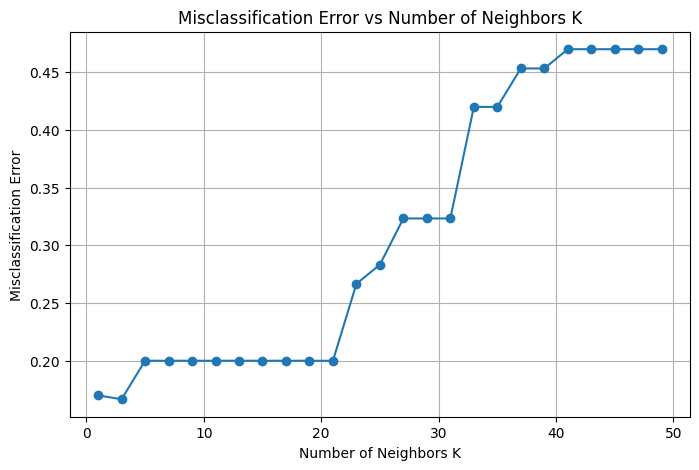

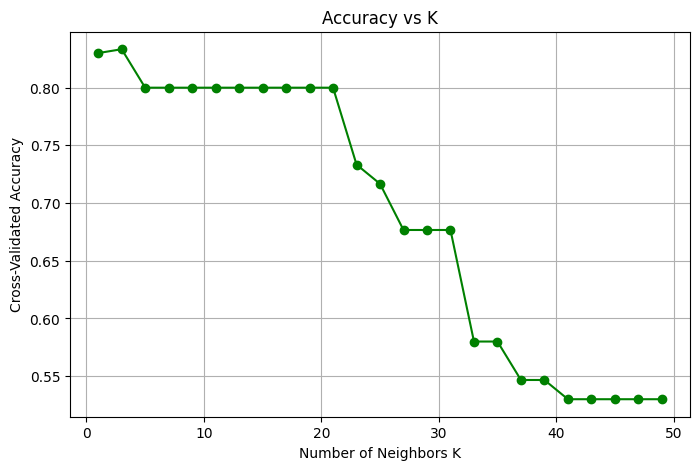

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define safe K range based on your dataset
total_samples = len(X)
max_safe_k = (total_samples * 9) // 10  # 90% of data for training in 10-fold CV
k_range = list(range(1, max_safe_k, 2))  # Odd K values only

# Store accuracy and misclassification error
accuracy_scores = []
error_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    mean_score = scores.mean()
    accuracy_scores.append(mean_score)
    error_scores.append(1 - mean_score)

# Get best K based on highest accuracy
best_k = k_range[np.argmax(accuracy_scores)]
print(f"✅ Best K = {best_k} with accuracy = {max(accuracy_scores):.2f}")

# Plot Misclassification Error
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_scores, marker='o')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs Number of Neighbors K")
plt.grid(True)
plt.show()

#  Plot Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracy_scores, marker='o', color='green')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

# Define KNN with best K for final model evaluation
knn_model = KNeighborsClassifier(n_neighbors=best_k)

✅ Best K = 3 with average accuracy = 0.83


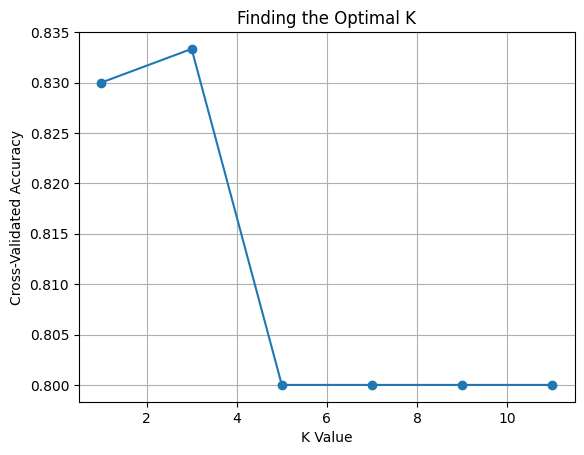

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Use full X and y (not split) for cross-validation
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"✅ Best K = {best_k} with average accuracy = {max(cv_scores):.2f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding the Optimal K')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# individual models
svm_model = best_svm_model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# ensemble model
ensemble_model = VotingClassifier(estimators=[
    ('SVM', svm_model),
    ('KNN', knn_model),
    ('RF', rf_model)
], voting='soft')

# Store all models in dictionary
models = {
    "SVM": svm_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "Ensemble": ensemble_model
}

# Function to calculate task-wise accuracy
def task_wise_accuracy(y_pred, model_name, X_test_original, y_test_original, df_original):
    X_test_copy = X_test_original.copy()
    X_test_copy['true_label'] = y_test_original.values
    X_test_copy['predicted_label'] = y_pred
    X_test_copy['task_type'] = df_original.loc[X_test_original.index, 'Label']
    X_test_copy['group'] = df_original.loc[X_test_original.index, 'Label_Class']

    task_accuracy_data = []
    for group in X_test_copy['group'].unique():
        for task_type in X_test_copy['task_type'].unique():
            subset = X_test_copy[(X_test_copy['group'] == group) & (X_test_copy['task_type'] == task_type)]
            if not subset.empty:
                accuracy = (subset['true_label'] == subset['predicted_label']).mean()
                task_accuracy_data.append({'group': group, 'task_type': task_type, 'accuracy': accuracy})

    task_group_accuracy = pd.DataFrame(task_accuracy_data)

    if not task_group_accuracy.empty:
        task_group_accuracy = task_group_accuracy.pivot(index='group', columns='task_type', values='accuracy')

        task_group_accuracy = task_group_accuracy.reindex(columns=[0, 1, 2])

        task_group_accuracy.index = task_group_accuracy.index.map({0: 'TD', 1: 'ASD'})
        task_group_accuracy.columns = ['Task 0', 'Task 1', 'Task 2']
    else:
        task_group_accuracy = pd.DataFrame(index=['TD', 'ASD'], columns=['Task 0', 'Task 1', 'Task 2'])


    print(f"🎯 Task-wise Accuracy Within Each Group ({model_name}):\n", task_group_accuracy)


# Evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n===== {name} Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=['TD', 'ASD'], zero_division=0))

    task_wise_accuracy(y_pred, name, X_test, y_test, df)


===== SVM Classification Report =====
              precision    recall  f1-score   support

          TD       1.00      0.67      0.80         6
         ASD       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12

🎯 Task-wise Accuracy Within Each Group (SVM):
        Task 0    Task 1  Task 2
group                          
TD        1.0  0.333333     1.0
ASD       1.0  1.000000     1.0

===== KNN Classification Report =====
              precision    recall  f1-score   support

          TD       0.60      1.00      0.75         6
         ASD       1.00      0.33      0.50         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62        12
weighted avg       0.80      0.67      0.62        12

🎯 Task-wise Accuracy Within Each Group (KNN):
        Task 0  Task 1    Task 2
group         

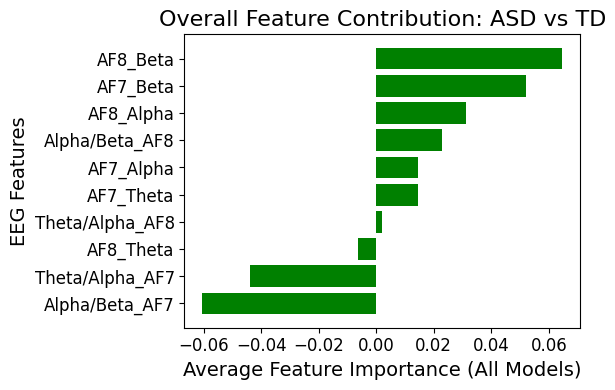

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# Run permutation importance for each model
result_svm = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_knn = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_rf = permutation_importance(rf_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_ensemble = permutation_importance(ensemble_model, X_test_scaled, y_test, n_repeats=10, random_state=42)

# Extract average importance
importances_avg = np.mean([
    result_svm.importances_mean,
    result_knn.importances_mean,
    result_rf.importances_mean,
    result_ensemble.importances_mean
], axis=0)

# Plot the final combined feature importance
sorted_idx = importances_avg.argsort()
plt.figure(figsize=(6, 4))

# Plotting bar chart
plt.barh(X.columns[sorted_idx], importances_avg[sorted_idx], color='green')

# Axis labels with larger fonts
plt.xlabel('Average Feature Importance (All Models)', fontsize=14)
plt.ylabel('EEG Features', fontsize=14)

# Axis tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Title
plt.title('Overall Feature Contribution: ASD vs TD', fontsize=16)

# Tight layout and high-resolution save
plt.tight_layout()
plt.savefig(f'plot_{1}.png', dpi=600, bbox_inches='tight')
plt.show()


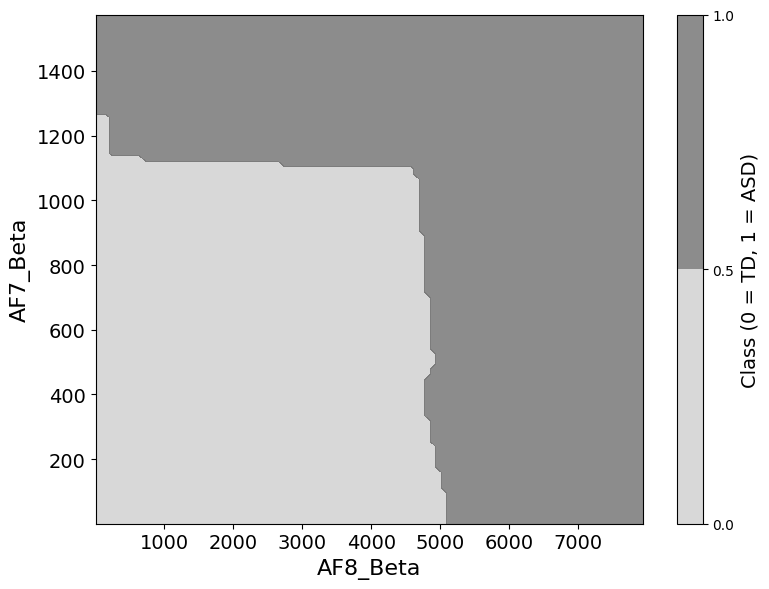

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the model (useing ensemble for best general performance)
model = ensemble_model

# Define feature names (must match column names)
feature_x = 'AF8_Beta'
feature_y = 'AF7_Beta'

# Create a meshgrid over feature ranges
x_range = np.linspace(X[feature_x].min(), X[feature_x].max(), 100)
y_range = np.linspace(X[feature_y].min(), X[feature_y].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

# Create a grid of input data points
grid = pd.DataFrame({feature_x: xx.ravel(), feature_y: yy.ravel()})

# Add 0s for all other features to complete dimensionality
for col in X.columns:
    if col not in [feature_x, feature_y]:
        grid[col] = 0

grid = grid[X.columns]

# Scale the grid using the same scaler used before
grid_scaled = scaler.transform(grid)

# Predict class labels on the grid
Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the classification map
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=1, cmap=plt.cm.binary, alpha=0.6)

# Axis labels with larger fonts
plt.xlabel(feature_x, fontsize=16)
plt.ylabel(feature_y, fontsize=16)

# Axis tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Classification Map Based on Top EEG Features (ASD vs TD)', fontsize=18)

# Colorbar label
cbar = plt.colorbar(label='Class (0 = TD, 1 = ASD)')
cbar.set_label('Class (0 = TD, 1 = ASD)', fontsize=14)


plt.tight_layout()
plt.savefig(f'classification_map_{feature_x}_{feature_y}.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import zipfile
import os
from google.colab import files

 Create ZIP of all PNG files
with zipfile.ZipFile("all_plots.zip", "w") as zipf:
    for file in os.listdir():
        if file.endswith(".png"):
            zipf.write(file)

files.download("all_plots.zip")

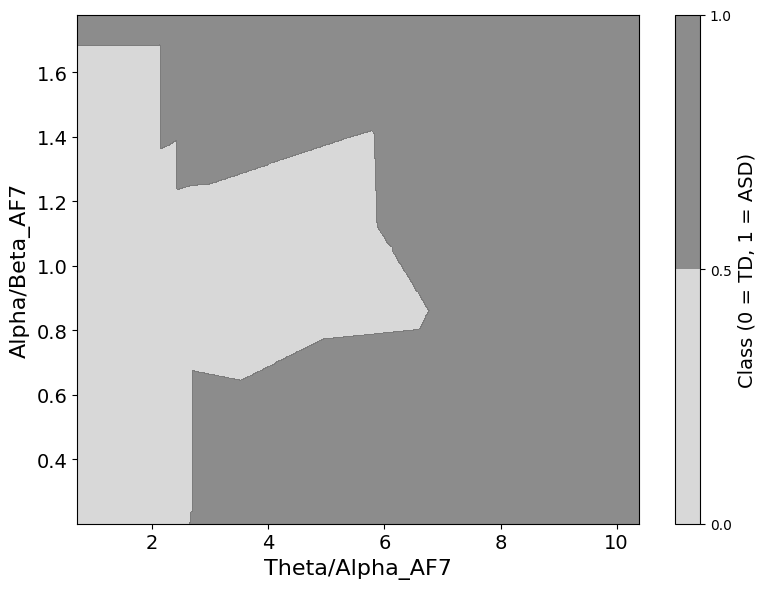

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the model (useing ensemble for best general performance)
model = ensemble_model

# Define feature names (must match column names)
feature_x = 'Theta/Alpha_AF7'
feature_y = 'Alpha/Beta_AF7'

# Create a meshgrid over feature ranges
x_range = np.linspace(X[feature_x].min(), X[feature_x].max(),500)
y_range = np.linspace(X[feature_y].min(), X[feature_y].max(), 500)
xx, yy = np.meshgrid(x_range, y_range)

# Create a grid of input data points
grid = pd.DataFrame({feature_x: xx.ravel(), feature_y: yy.ravel()})

# Add 0s for all other features to complete dimensionality
for col in X.columns:
    if col not in [feature_x, feature_y]:
        grid[col] = 0

grid = grid[X.columns]

# Scale the grid using the same scaler used before
grid_scaled = scaler.transform(grid)

# Predict class labels on the grid
Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the classification map
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=1, cmap=plt.cm.binary, alpha=0.6)
plt.xlabel(feature_x, fontsize=16)
plt.ylabel(feature_y, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Classification Map Based on Top EEG Features (ASD vs TD)', fontsize=18)
cbar = plt.colorbar(label='Class (0 = TD, 1 = ASD)')
cbar.set_label('Class (0 = TD, 1 = ASD)', fontsize=14)

plt.tight_layout()
plt.savefig(f'classification_map_{feature_x.replace("/", "_")}_{feature_y.replace("/", "_")}.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
 himport numpy as np
from scipy import stats
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Assuming best_svm_model and best_k are defined in previous cells
svm_model = best_svm_model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


# Define custom scorers to handle zero division
custom_precision_scorer = make_scorer(precision_score, zero_division=0)
custom_recall_scorer = make_scorer(recall_score, zero_division=0)
custom_f1_scorer = make_scorer(f1_score, zero_division=0)


# Function to perform cross-validation and print metrics
def evaluate_model(model, model_name, X, y):
    print(f"\n===== {model_name} Cross-Validation Results =====")

    # Useing stratified folds to preserve class balance
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Perform cross-validation for each metric using custom scorers
    cv_scores_accuracy = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_scores_precision = cross_val_score(model, X, y, cv=skf, scoring=custom_precision_scorer)
    cv_scores_recall = cross_val_score(model, X, y, cv=skf, scoring=custom_recall_scorer)
    cv_scores_f1 = cross_val_score(model, X, y, cv=skf, scoring=custom_f1_scorer)


    # Calculate and print the mean and standard deviation for each metric
    print(f"Accuracy: {np.mean(cv_scores_accuracy):.2f} ± {np.std(cv_scores_accuracy):.2f}")
    print(f"Precision: {np.mean(cv_scores_precision):.2f} ± {np.std(cv_scores_precision):.2f}")
    print(f"Recall: {np.mean(cv_scores_recall):.2f} ± {np.std(cv_scores_recall):.2f}")
    print(f"F1-Score: {np.mean(cv_scores_f1):.2f} ± {np.std(cv_scores_f1):.2f}")

    # Calculate and print the confidence interval for accuracy
    mean_acc = np.mean(cv_scores_accuracy)
    accuracies = np.array(cv_scores_accuracy)
    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(accuracies)-1,
        loc=mean_acc,
        scale=stats.sem(accuracies)
    )
    print(f"Accuracy (95% CI): {mean_acc:.2f} ({ci_low:.2f} - {ci_high:.2f})")


# Evaluate each model in the dictionary
for name, model in models.items():
    evaluate_model(model, name, X, y)



===== SVM Cross-Validation Results =====
Accuracy: 0.84 ± 0.16
Precision: 0.84 ± 0.21
Recall: 0.90 ± 0.15
F1-Score: 0.85 ± 0.14
Accuracy (95% CI): 0.84 (0.72 - 0.96)

===== KNN Cross-Validation Results =====
Accuracy: 0.84 ± 0.12
Precision: 0.97 ± 0.07
Recall: 0.70 ± 0.27
F1-Score: 0.78 ± 0.18
Accuracy (95% CI): 0.84 (0.75 - 0.93)

===== Random Forest Cross-Validation Results =====
Accuracy: 0.88 ± 0.08
Precision: 0.95 ± 0.10
Recall: 0.82 ± 0.19
F1-Score: 0.86 ± 0.11
Accuracy (95% CI): 0.88 (0.82 - 0.94)

===== Ensemble Cross-Validation Results =====
Accuracy: 0.90 ± 0.08
Precision: 0.97 ± 0.07
Recall: 0.82 ± 0.19
F1-Score: 0.87 ± 0.11
Accuracy (95% CI): 0.90 (0.83 - 0.96)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

# Store importances across folds from your previous CV loop

results = {m: [] for m in models.keys()}

# Collect per-fold feature importances
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for name, model in models.items():
        model.fit(X_train, y_train)

        if name == "Random Forest":
            importances = model.feature_importances_
        else:
            perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
            importances = perm.importances_mean

        results[name].append(importances)

# Summarize stability across folds
stability_results = {}
for name, folds in results.items():
    fold_importances = np.array(folds)  # shape = (n_folds, n_features)
    mean_imp = fold_importances.mean(axis=0)
    std_imp = fold_importances.std(axis=0)

    # Spearman correlation across folds
    correlations = []
    for i in range(len(folds)):
        for j in range(i+1, len(folds)):
            corr, _ = spearmanr(folds[i], folds[j])
            correlations.append(corr)

    stability_results[name] = pd.DataFrame({
        "Feature": X.columns,
        "MeanImportance": mean_imp,
        "StdAcrossFolds": std_imp
    }).sort_values("MeanImportance", ascending=False)

    print(f"\n{name} - Avg Spearman correlation across folds: {np.mean(correlations):.3f}")

stability_results["Random Forest"].head(10)


SVM - Avg Spearman correlation across folds: 0.128

KNN - Avg Spearman correlation across folds: 0.592

Random Forest - Avg Spearman correlation across folds: 0.868

Ensemble - Avg Spearman correlation across folds: 0.523


,Feature,MeanImportance,StdAcrossFolds
4,AF8_Beta,0.175488,0.021175
3,AF8_Alpha,0.170215,0.013669
0,AF7_Alpha,0.141585,0.012017
5,AF8_Theta,0.122218,0.014815
1,AF7_Beta,0.121254,0.026156
6,Theta/Alpha_AF7,0.087548,0.019507
8,Theta/Alpha_AF8,0.071965,0.024148
2,AF7_Theta,0.061994,0.007674
7,Alpha/Beta_AF7,0.026300,0.005816
9,Alpha/Beta_AF8,0.021433,0.005482
